# Task 1 — Population Exploration

This notebook characterises the PBSHM challenge dataset: a population of 50 simulated shear-frame structures with 4–8 storeys, of which 15 are damaged (localised stiffness reduction at one storey).

The guiding question is: **which measurable quantities carry information about damage, and why?**

We proceed in five steps:
1. Structural diversity — sizes and geometry
2. Physical meaning of the dominant modal frequency (with a worked example)
3. Population graph analysis
4. Why raw features do not separate damaged structures
5. Proposal of physically-motivated damage-sensitive features

In [1]:
# ── Imports and data loading ──────────────────────────────────────────────────
from setup_0 import *

structures, labels_df, label_map, damage_storey_map, pop_edges, pop_weights = load_data()

n_structures = len(structures)
n_damaged = int(labels_df.damaged.sum())
n_healthy = n_structures - n_damaged

print(f"Population: {n_structures} structures ({n_healthy} healthy, {n_damaged} damaged)")
print(f"Storey range: {min(s['n_storeys'] for s in structures)}–"
      f"{max(s['n_storeys'] for s in structures)}")
print(f"Node features: {structures[0]['feature_names']}")
print(f"Population graph: {len(pop_edges)} directed edges")

All data files ready.
Population: 50 structures (35 healthy, 15 damaged)
Storey range: 4–8
Node features: ['height_m', 'dominant_modal_frequency_Hz']
Population graph: 250 directed edges


## 1.1 Structural Diversity

The population spans structures with 4 to 8 storeys. Since the number of storeys determines the number of degrees of freedom — and hence the number of natural frequencies and mode shapes — structures of different sizes have fundamentally different dynamic signatures. Any detection method must handle this heterogeneity.

Storey heights are drawn independently from $U(3.0, 5.0)$ m, so total building height scales with the number of storeys but with substantial within-group variance. Damage is distributed across all sizes with no obvious concentration.

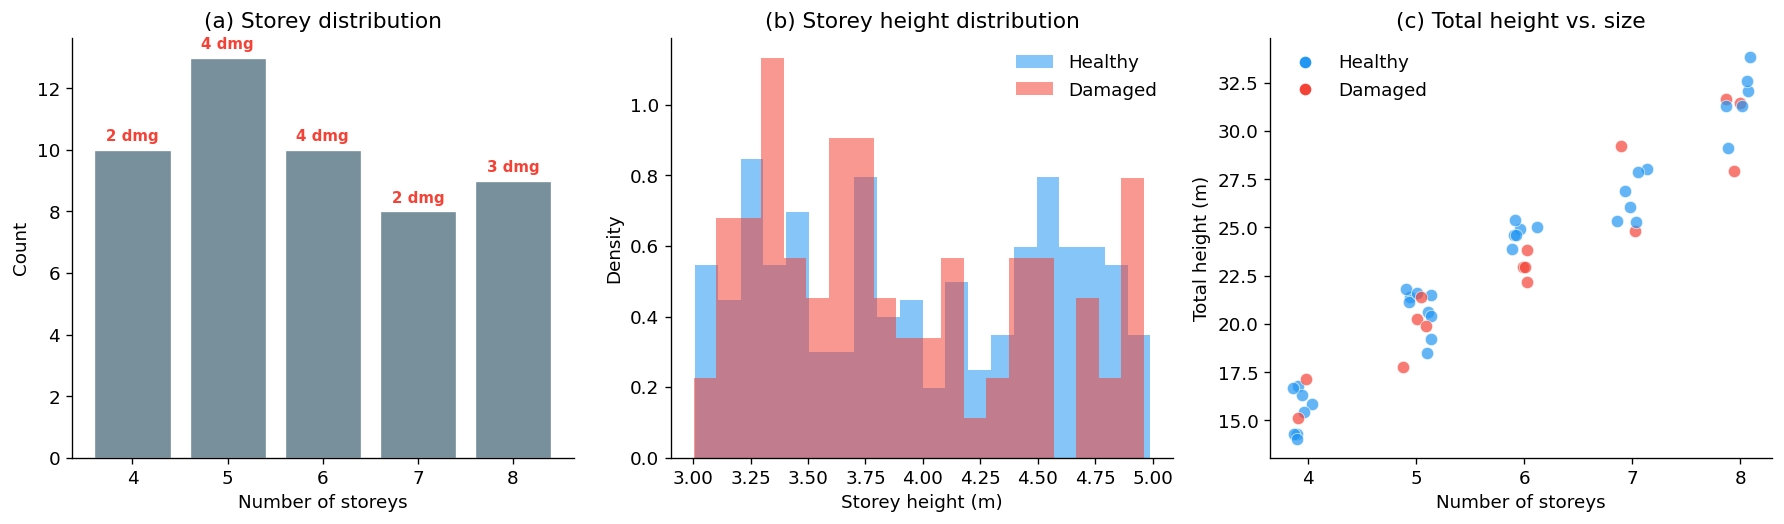

Storey counts: {4: 10, 5: 13, 6: 10, 7: 8, 8: 9}
Damaged per size: {4: 2, 5: 4, 6: 4, 7: 2, 8: 3}


In [2]:
# ── 1.1 Structural diversity ─────────────────────────────────────────────────
storey_counts = Counter(s['n_storeys'] for s in structures)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) Storey count distribution, annotated with damaged count
sizes = sorted(storey_counts.keys())
counts = [storey_counts[s] for s in sizes]

bars = axes[0].bar(sizes, counts, color=NEUTRAL_COLOR, edgecolor='white', linewidth=0.8)
for i, size in enumerate(sizes):
    n_dmg = sum(1 for s in structures 
                if s['n_storeys'] == size and label_map[s['structure_id']] == 1)
    if n_dmg > 0:
        axes[0].text(size, counts[i] + 0.3, f'{n_dmg} dmg', 
                     ha='center', fontsize=9, color=DAMAGED_COLOR, fontweight='bold')
axes[0].set_xlabel('Number of storeys')
axes[0].set_ylabel('Count')
axes[0].set_title('(a) Storey distribution')
axes[0].set_xticks(sizes)

# (b) Storey height distributions — healthy vs damaged
for dmg_val, name in LABEL_NAMES.items():
    h = [n['height_m'] for s in structures if label_map[s['structure_id']] == dmg_val
         for n in s['node_features']]
    axes[1].hist(h, bins=20, alpha=0.55, color=PALETTE[dmg_val], label=name, density=True)
axes[1].set_xlabel('Storey height (m)')
axes[1].set_ylabel('Density')
axes[1].set_title('(b) Storey height distribution')
axes[1].legend(frameon=False)

# (c) Total height vs n_storeys
for s in structures:
    total_h = sum(n['height_m'] for n in s['node_features'])
    dmg = label_map[s['structure_id']]
    jitter = np.random.uniform(-0.15, 0.15)
    axes[2].scatter(s['n_storeys'] + jitter, total_h, c=PALETTE[dmg],
                    s=55, alpha=0.7, edgecolors='white', linewidth=0.5, zorder=3)
axes[2].set_xlabel('Number of storeys')
axes[2].set_ylabel('Total height (m)')
axes[2].set_title('(c) Total height vs. size')
damage_legend(axes[2])

plt.tight_layout()
plt.show()

print(f"Storey counts: { {s: storey_counts[s] for s in sizes} }")
print(f"Damaged per size: { {s: sum(1 for st in structures if st['n_storeys']==s and label_map[st['structure_id']]==1) for s in sizes} }")

## 1.2 The Dominant Modal Frequency — A Physical Worked Example

The feature `dominant_modal_frequency_Hz` is not a raw sensor measurement. It is a **processed quantity** derived from the modal analysis of each structure. Understanding how it is constructed — and how damage affects it — is essential before any modelling attempt.

**Construction process:**
1. Solve the eigenvalue problem $\mathbf{K}\boldsymbol{\phi} = \omega^2 \mathbf{M}\boldsymbol{\phi}$ → obtain $N$ natural frequencies $f_1 < \ldots < f_N$ and mode shapes $\boldsymbol{\phi}_1, \ldots, \boldsymbol{\phi}_N$
2. For each floor $j$, identify the mode with the largest amplitude: $k^* = \arg\max_i |\phi_i(j)|$
3. Assign that mode's frequency (with measurement noise) as the dominant modal frequency at floor $j$

This means: **the same natural frequency can appear at multiple floors** (when the same mode dominates), and **damage can cause the dominant mode to switch at a floor**, producing a discontinuous jump in the observed frequency — not just a smooth shift.

To make this concrete, we build a simple 5-storey shear frame and compare its healthy and damaged frequency profiles.

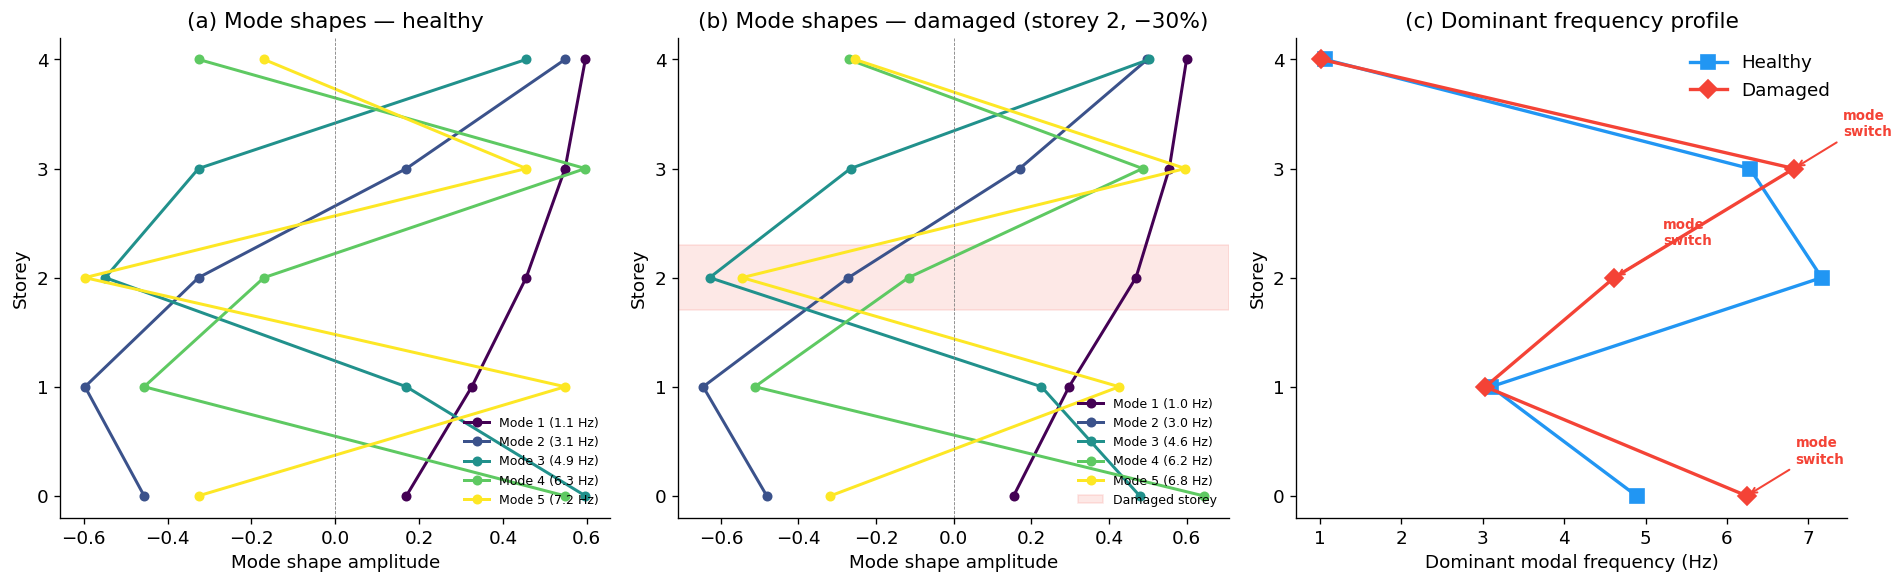

Natural frequencies (Hz):
  Healthy: [1.06 3.1  4.89 6.28 7.16]
  Damaged: [1.02 3.03 4.61 6.24 6.82]
  Shift:   [-4.2 -2.2 -5.6 -0.6 -4.7]%

Dominant mode per floor:
  Healthy: [3 2 5 4 1]
  Damaged: [4 2 3 5 1]
  Switches at storeys: [0 2 3]


In [3]:
# ── 1.2 Worked example: 5-DOF shear frame ────────────────────────────────────
# Uniform properties for clarity
n_ex = 5
masses = np.full(n_ex, 2000.0)           # kg
stiffnesses = np.full(n_ex, 1.1e6)       # N/m

# ── Healthy structure ──
M_h, K_h = build_shear_frame_matrices(masses, stiffnesses)
freqs_h, modes_h = solve_eigenproblem(M_h, K_h)
dom_freq_h, dom_mode_h = dominant_modal_frequency(freqs_h, modes_h)

# ── Damaged: 30% stiffness reduction at storey 2 ──
stiffnesses_d = stiffnesses.copy()
stiffnesses_d[2] *= 0.70
M_d, K_d = build_shear_frame_matrices(masses, stiffnesses_d)
freqs_d, modes_d = solve_eigenproblem(M_d, K_d)
dom_freq_d, dom_mode_d = dominant_modal_frequency(freqs_d, modes_d)

# ── Figure ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
storeys = np.arange(n_ex)

# (a) Mode shapes — healthy
cmap = plt.cm.viridis
mode_colors = [cmap(i / (n_ex - 1)) for i in range(n_ex)]
for i in range(n_ex):
    axes[0].plot(modes_h[:, i], storeys, 'o-', color=mode_colors[i], 
                 linewidth=1.8, markersize=5, label=f'Mode {i+1} ({freqs_h[i]:.1f} Hz)')
axes[0].axvline(0, color='gray', linewidth=0.5, linestyle='--')
axes[0].set_xlabel('Mode shape amplitude')
axes[0].set_ylabel('Storey')
axes[0].set_yticks(storeys)
axes[0].set_title('(a) Mode shapes — healthy')
axes[0].legend(fontsize=7.5, frameon=False, loc='lower right')

# (b) Mode shapes — damaged
for i in range(n_ex):
    axes[1].plot(modes_d[:, i], storeys, 'o-', color=mode_colors[i],
                 linewidth=1.8, markersize=5, label=f'Mode {i+1} ({freqs_d[i]:.1f} Hz)')
axes[1].axvline(0, color='gray', linewidth=0.5, linestyle='--')
axes[1].axhspan(1.7, 2.3, color=DAMAGED_COLOR, alpha=0.12, label='Damaged storey')
axes[1].set_xlabel('Mode shape amplitude')
axes[1].set_ylabel('Storey')
axes[1].set_yticks(storeys)
axes[1].set_title('(b) Mode shapes — damaged (storey 2, −30%)')
axes[1].legend(fontsize=7.5, frameon=False, loc='lower right')

# (c) Dominant modal frequency profiles — comparison
axes[2].plot(dom_freq_h, storeys, 's-', color=HEALTHY_COLOR, linewidth=2,
             markersize=8, label='Healthy', zorder=3)
axes[2].plot(dom_freq_d, storeys, 'D-', color=DAMAGED_COLOR, linewidth=2,
             markersize=8, label='Damaged', zorder=3)

# Annotate mode switches
switches = np.where(dom_mode_h != dom_mode_d)[0]
for sw in switches:
    axes[2].annotate('mode\nswitch', xy=(dom_freq_d[sw], sw),
                     xytext=(dom_freq_d[sw] + 0.6, sw + 0.3),
                     fontsize=8, color=DAMAGED_COLOR, fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color=DAMAGED_COLOR, lw=1.2))

axes[2].set_xlabel('Dominant modal frequency (Hz)')
axes[2].set_ylabel('Storey')
axes[2].set_yticks(storeys)
axes[2].set_title('(c) Dominant frequency profile')
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()

# Summary
print("Natural frequencies (Hz):")
print(f"  Healthy: {np.round(freqs_h, 2)}")
print(f"  Damaged: {np.round(freqs_d, 2)}")
print(f"  Shift:   {np.round((freqs_d - freqs_h) / freqs_h * 100, 1)}%")
print(f"\nDominant mode per floor:")
print(f"  Healthy: {dom_mode_h}")
print(f"  Damaged: {dom_mode_d}")
print(f"  Switches at storeys: {switches}")

## 1.3 Population Graph Analysis

The provided population graph connects each structure to its $k=5$ nearest neighbours using cosine similarity on a geometry summary vector $\mathbf{g}_i = [n_\text{storeys},\; \bar{h},\; \sigma_h,\; \Sigma h]$. This graph is meant to encode structural similarity across the population.

Two questions guide our analysis:
1. **Does the graph capture meaningful structural similarity?** — i.e., are edge weights discriminative, or are all structures nearly equidistant?
2. **Is damage state clustered in the graph?** — i.e., do damaged structures tend to be neighbours of other damaged structures?

If neither holds, the population graph in its current form may add little value for damage detection — motivating us to consider alternatives in Task 5.

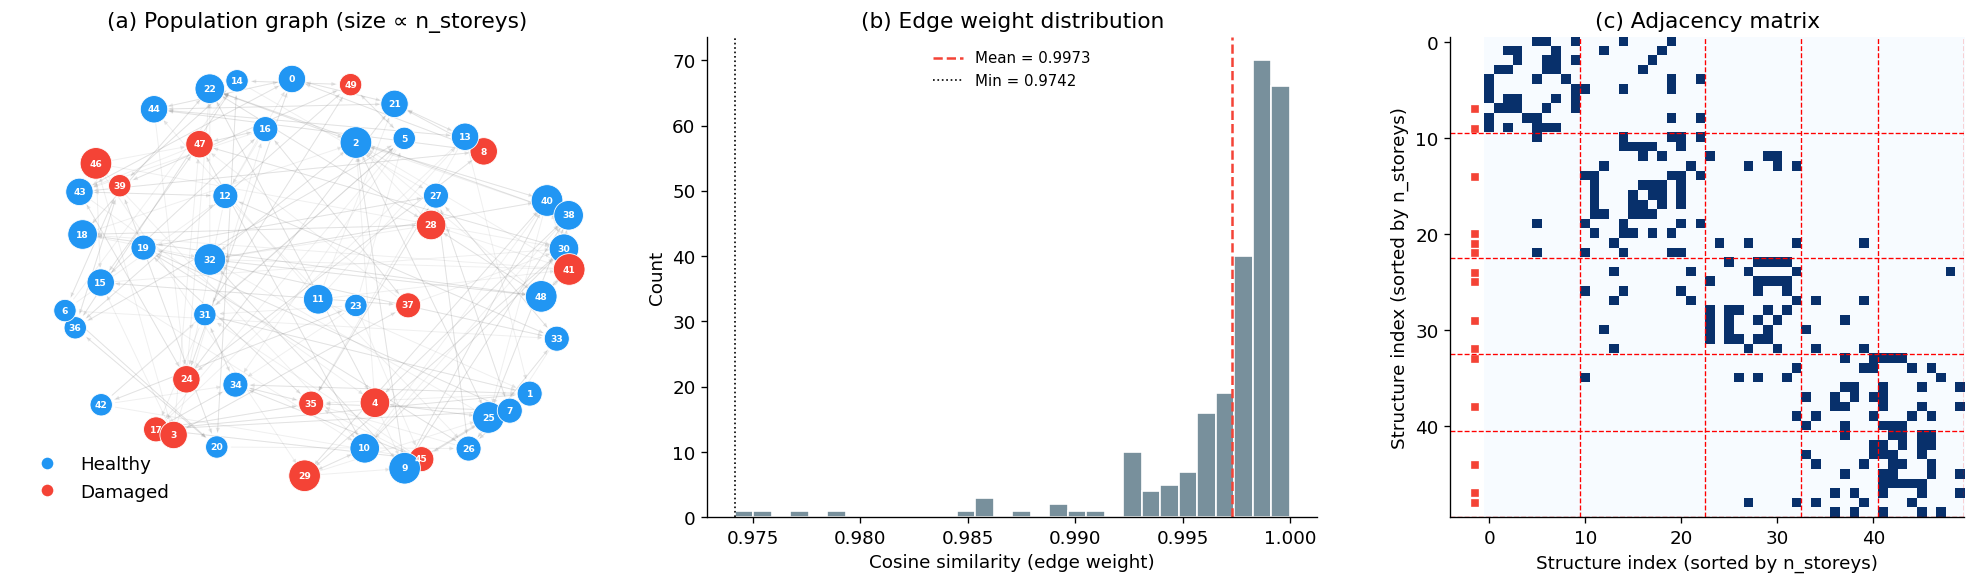

Edge homophily:  0.560 (random expectation: 0.580)
Reciprocity:     71.2% of edges are reciprocal
Weight range:    [0.9742, 1.0000] — spread of only 0.0258


In [4]:
# ── 1.3 Population graph ─────────────────────────────────────────────────────
G_pop = nx.DiGraph()
for _, row in pop_edges.iterrows():
    G_pop.add_edge(int(row['source']), int(row['target']))

for _, row in pop_weights.iterrows():
    src, tgt = int(row['source']), int(row['target'])
    if G_pop.has_edge(src, tgt):
        G_pop[src][tgt]['weight'] = row['cosine_similarity']

for s in structures:
    sid = s['structure_id']
    G_pop.nodes[sid]['n_storeys'] = s['n_storeys']
    G_pop.nodes[sid]['damaged'] = label_map[sid]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) Graph layout — colored by label, sized by n_storeys
pos = nx.spring_layout(G_pop, seed=SEED, k=1.8)
node_colors = [PALETTE[label_map[n]] for n in G_pop.nodes()]
node_sizes = [G_pop.nodes[n]['n_storeys'] * 45 for n in G_pop.nodes()]

nx.draw_networkx_edges(G_pop, pos, ax=axes[0], alpha=0.12, arrows=True,
                        arrowsize=5, edge_color='gray', width=0.6)
nx.draw_networkx_nodes(G_pop, pos, ax=axes[0], node_color=node_colors,
                        node_size=node_sizes, edgecolors='white', linewidths=0.5)
nx.draw_networkx_labels(G_pop, pos, ax=axes[0], font_size=5.5,
                         font_color='white', font_weight='bold')
axes[0].set_title('(a) Population graph (size ∝ n_storeys)')
axes[0].axis('off')
damage_legend(axes[0], loc='lower left')

# (b) Edge weight distribution
weights = [G_pop[u][v].get('weight', 1.0) for u, v in G_pop.edges()]
axes[1].hist(weights, bins=30, color=NEUTRAL_COLOR, edgecolor='white')
axes[1].axvline(np.mean(weights), color=DAMAGED_COLOR, linestyle='--', linewidth=1.5,
                label=f'Mean = {np.mean(weights):.4f}')
axes[1].axvline(np.min(weights), color='black', linestyle=':', linewidth=1,
                label=f'Min = {np.min(weights):.4f}')
axes[1].set_xlabel('Cosine similarity (edge weight)')
axes[1].set_ylabel('Count')
axes[1].set_title('(b) Edge weight distribution')
axes[1].legend(frameon=False, fontsize=9)

# (c) Adjacency matrix ordered by n_storeys — reveals block structure
ordered_nodes = sorted(G_pop.nodes(), key=lambda n: (G_pop.nodes[n]['n_storeys'], n))
node_to_idx = {n: i for i, n in enumerate(ordered_nodes)}
adj = np.zeros((n_structures, n_structures))
for u, v in G_pop.edges():
    adj[node_to_idx[u], node_to_idx[v]] = 1

im = axes[2].imshow(adj, cmap='Blues', interpolation='nearest', aspect='equal')
# Mark group boundaries
cumulative = 0
for size in sorted(storey_counts.keys()):
    cumulative += storey_counts[size]
    axes[2].axhline(cumulative - 0.5, color='red', linewidth=0.8, linestyle='--')
    axes[2].axvline(cumulative - 0.5, color='red', linewidth=0.8, linestyle='--')

# Mark damaged structures on the margin
for node in ordered_nodes:
    if label_map[node] == 1:
        idx = node_to_idx[node]
        axes[2].plot(-1.5, idx, 's', color=DAMAGED_COLOR, markersize=3.5, clip_on=False)

axes[2].set_xlabel('Structure index (sorted by n_storeys)')
axes[2].set_ylabel('Structure index (sorted by n_storeys)')
axes[2].set_title('(c) Adjacency matrix')

plt.tight_layout()
plt.show()

# ── Quantitative assessment ──
n_same_label = sum(1 for u, v in G_pop.edges() if label_map[u] == label_map[v])
n_edges_total = G_pop.number_of_edges()
expected_homophily = (n_healthy/n_structures)**2 + (n_damaged/n_structures)**2

# Reciprocity
n_reciprocal = sum(1 for u, v in G_pop.edges() if G_pop.has_edge(v, u))

print(f"Edge homophily:  {n_same_label/n_edges_total:.3f} "
      f"(random expectation: {expected_homophily:.3f})")
print(f"Reciprocity:     {n_reciprocal/n_edges_total:.1%} of edges are reciprocal")
print(f"Weight range:    [{min(weights):.4f}, {max(weights):.4f}] "
      f"— spread of only {max(weights)-min(weights):.4f}")

## 1.4 Why Raw Features Do Not Separate Damaged Structures

An obvious first attempt is to aggregate frequency statistics per structure (mean, min, max, std) and check whether they differ between healthy and damaged groups. The figure below shows this fails: the distributions overlap almost completely.

**The physical reason** is that each structure has independently sampled masses $m_i \sim U(1500, 2500)$ kg and stiffnesses $k_i \sim U(0.8, 1.4) \times 10^6$ N/m. A healthy structure with inherently low stiffness can have lower natural frequencies than a damaged structure with high baseline stiffness. In other words, **inter-structure variability in the undamaged properties dominates over the frequency shift caused by damage**, making absolute frequency statistics poor discriminators.

This motivates a shift toward **relative, within-structure features** that capture spatial patterns in the frequency profile rather than absolute values.

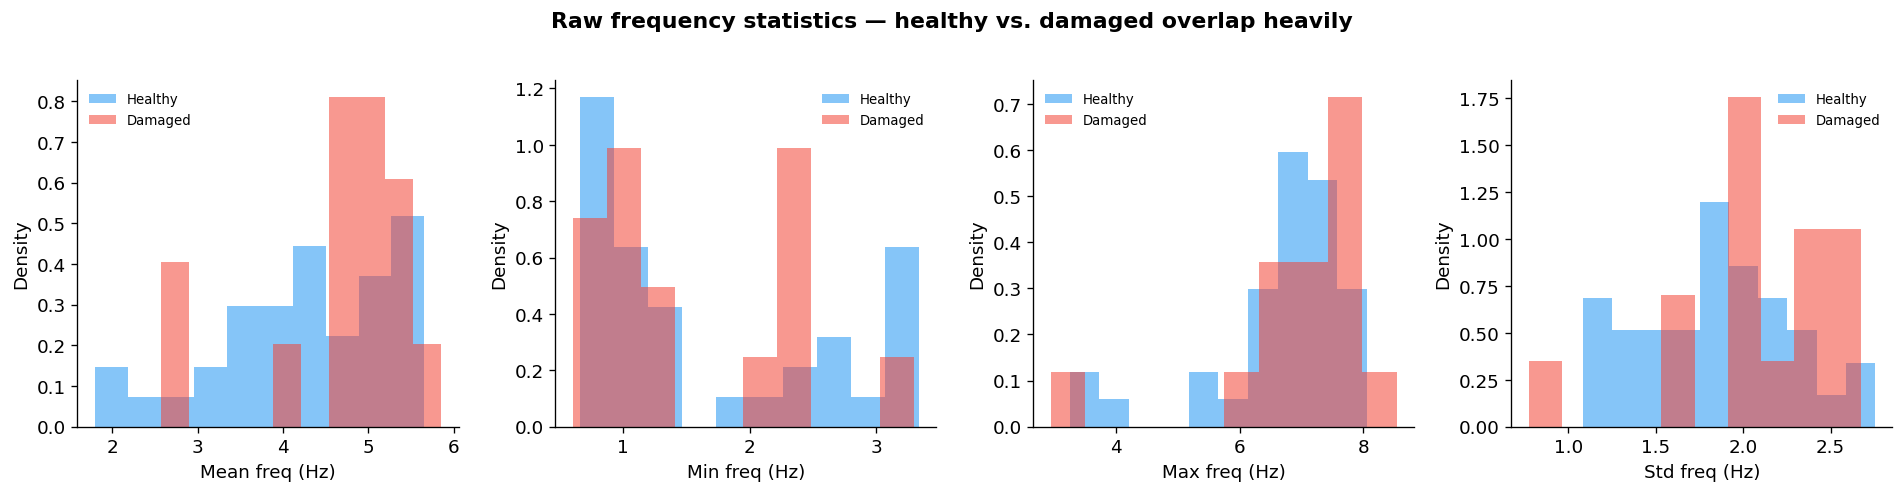

Univariate ROC-AUC (direction-adjusted) for raw features:
  freq_mean     AUC = 0.610  
  freq_min      AUC = 0.530  ←
  freq_max      AUC = 0.619  
  freq_std      AUC = 0.676  


In [5]:
# ── 1.4 Raw feature separation ───────────────────────────────────────────────
df_feat = build_feature_matrix(structures, label_map)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
raw_features = ['freq_mean', 'freq_min', 'freq_max', 'freq_std']
raw_labels = ['Mean freq (Hz)', 'Min freq (Hz)', 'Max freq (Hz)', 'Std freq (Hz)']

for ax, feat, xlabel in zip(axes, raw_features, raw_labels):
    for dmg_val, name in LABEL_NAMES.items():
        subset = df_feat[df_feat.damaged == dmg_val]
        ax.hist(subset[feat], bins=10, alpha=0.55, color=PALETTE[dmg_val],
                label=name, density=True)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend(frameon=False, fontsize=8)

fig.suptitle('Raw frequency statistics — healthy vs. damaged overlap heavily',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Quantify overlap with univariate ROC-AUC
from sklearn.metrics import roc_auc_score

print("Univariate ROC-AUC (direction-adjusted) for raw features:")
for feat in raw_features:
    vals = df_feat[feat].values
    y = df_feat['damaged'].values
    auc = roc_auc_score(y, vals)
    auc_adj = max(auc, 1 - auc)
    print(f"  {feat:<12s}  AUC = {auc_adj:.3f}  {'←' if auc_adj < 0.6 else ''}")

## 1.5 Damage-Sensitive Features — Physical Motivation

Since absolute frequency values are confounded by inter-structure variability, we need features that capture **how frequencies are distributed within a structure** — patterns that damage disrupts regardless of the baseline properties.

The physical reasoning draws on what we learned in §1.2:

| Feature | Physical rationale |
|---|---|
| `freq_over_h_std` | Normalising frequency by storey height removes part of the geometric variability. The standard deviation of this ratio captures how irregular the frequency-to-height relationship is — damage disrupts this regularity. |
| `freq_std` | While the mean frequency is confounded, the spread within a structure is more sensitive to damage: a local stiffness drop can push one mode's dominance range, increasing internal dispersion. |
| `freq_skew` | In a healthy frame, the dominant frequency profile is roughly symmetric or mildly skewed. Damage at a specific storey can pull frequencies asymmetrically, altering the skewness. |
| `second_diff_max` | The maximum second difference $\max_i |f_{i+2} - 2f_{i+1} + f_i|$ measures the sharpest "kink" in the frequency profile. This directly captures the mode-switching discontinuity caused by local damage. |
| `grad_max` | The largest single jump between adjacent storeys. Related to `second_diff_max` but captures first-order rather than second-order discontinuities. |

We now compute these features for all structures and assess their univariate discriminative power, then close Task 1 with a summary ranking.

## Summary of Task 1

**Key findings:**

1. **Population heterogeneity**: structures span 4–8 storeys with random heights, masses, and stiffnesses. This creates substantial inter-structure variability that masks damage effects in absolute measurements.

2. **The dominant modal frequency is a processed quantity**: it reflects which mode shape has the largest amplitude at each floor. Damage causes local stiffness reduction → mode shape redistribution → the dominant mode can *switch* at affected floors, producing spatial discontinuities in the frequency profile (§1.2).

3. **Raw frequency statistics fail**: mean, min, max, and std of frequencies all show heavy overlap between healthy and damaged groups (AUC ≈ 0.53–0.62). A healthy structure with low baseline stiffness is indistinguishable from a damaged structure with high baseline stiffness.

4. **The population graph is weakly informative**: edge weights (cosine similarity on geometry summaries) are all > 0.97, and damage homophily is at chance level. The graph captures size similarity, not damage-relevant similarity.

5. **Physically-motivated features improve separation**: features that capture *within-structure spatial patterns* — particularly `freq_over_h_std` (AUC ≈ 0.70), `freq_std`, `freq_skew`, and `second_diff_max` (AUC ≈ 0.67) — exploit the mode-switching mechanism identified in the worked example.

**Implications for subsequent tasks:**
- **Task 2**: we will build classifiers on the top-ranked engineered features, keeping models simple given $n = 50$
- **Task 3**: we will check whether these features produce natural clusters or anomaly separation without labels
- **Task 4**: the chain graph is a natural fit for GNNs — message passing along adjacent storeys can propagate exactly the spatial gradient information that our best features capture
- **Task 5**: the provided population graph needs rethinking; a modal-feature-based graph may be more informative

In [6]:
# ── Task 1 — Closing summary table ───────────────────────────────────────────
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_ind

engineered_features = [
    ('freq_over_h_std',    'Std(freq / height)'),
    ('freq_std',           'Std(freq)'),
    ('freq_skew',          'Skewness(freq)'),
    ('second_diff_max',    'Max 2nd difference'),
    ('grad_max',           'Max gradient'),
    ('grad_mean',          'Mean gradient'),
    ('freq_cv',            'CV(freq)'),
    ('freq_min_max_ratio', 'Min/Max ratio'),
    ('n_unique_freq_ratio','Unique freq ratio'),
]

auc_ranking = []
for feat, pretty_name in engineered_features:
    vals = df_feat[feat].values
    y = df_feat['damaged'].values
    auc = roc_auc_score(y, vals)
    auc_adj = max(auc, 1 - auc)
    _, p = ttest_ind(df_feat.loc[df_feat.damaged == 0, feat],
                     df_feat.loc[df_feat.damaged == 1, feat])
    h_mean = df_feat.loc[df_feat.damaged == 0, feat].mean()
    d_mean = df_feat.loc[df_feat.damaged == 1, feat].mean()
    auc_ranking.append((auc_adj, feat, pretty_name, p, h_mean, d_mean))

auc_ranking.sort(key=lambda x: -x[0])

summary_data = []
for auc_adj, feat, pretty_name, p, h_mean, d_mean in auc_ranking:
    summary_data.append({
        'Feature': pretty_name,
        'Code name': feat,
        'AUC': round(auc_adj, 3),
        'p-value': round(p, 4),
        'Healthy mean': round(h_mean, 3),
        'Damaged mean': round(d_mean, 3),
        'Selected': '✓' if auc_adj >= 0.65 else '',
    })

df_summary = pd.DataFrame(summary_data)
print("Feature ranking for damage detection (univariate ROC-AUC):\n")
print(df_summary.to_string(index=False))



Feature ranking for damage detection (univariate ROC-AUC):

            Feature            Code name    AUC  p-value  Healthy mean  Damaged mean Selected
 Std(freq / height)      freq_over_h_std  0.695   0.0402         0.482         0.566        ✓
          Std(freq)             freq_std  0.676   0.0683         1.838         2.099        ✓
 Max 2nd difference      second_diff_max  0.670   0.0821         6.680         7.976        ✓
     Skewness(freq)            freq_skew  0.667   0.0617        -0.067        -0.420        ✓
       Max gradient             grad_max  0.627   0.2240         4.439         4.941         
      Mean gradient            grad_mean  0.585   0.3698         2.369         2.584         
      Min/Max ratio   freq_min_max_ratio  0.560   0.4941         0.255         0.227         
  Unique freq ratio  n_unique_freq_ratio  0.522   0.6605         0.678         0.659         
           CV(freq)              freq_cv  0.510   0.9156         0.461         0.466         
